<a href="https://colab.research.google.com/github/zahyalabiyyu-tech/tugas1_pcd/blob/main/tugas%20Minggu%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

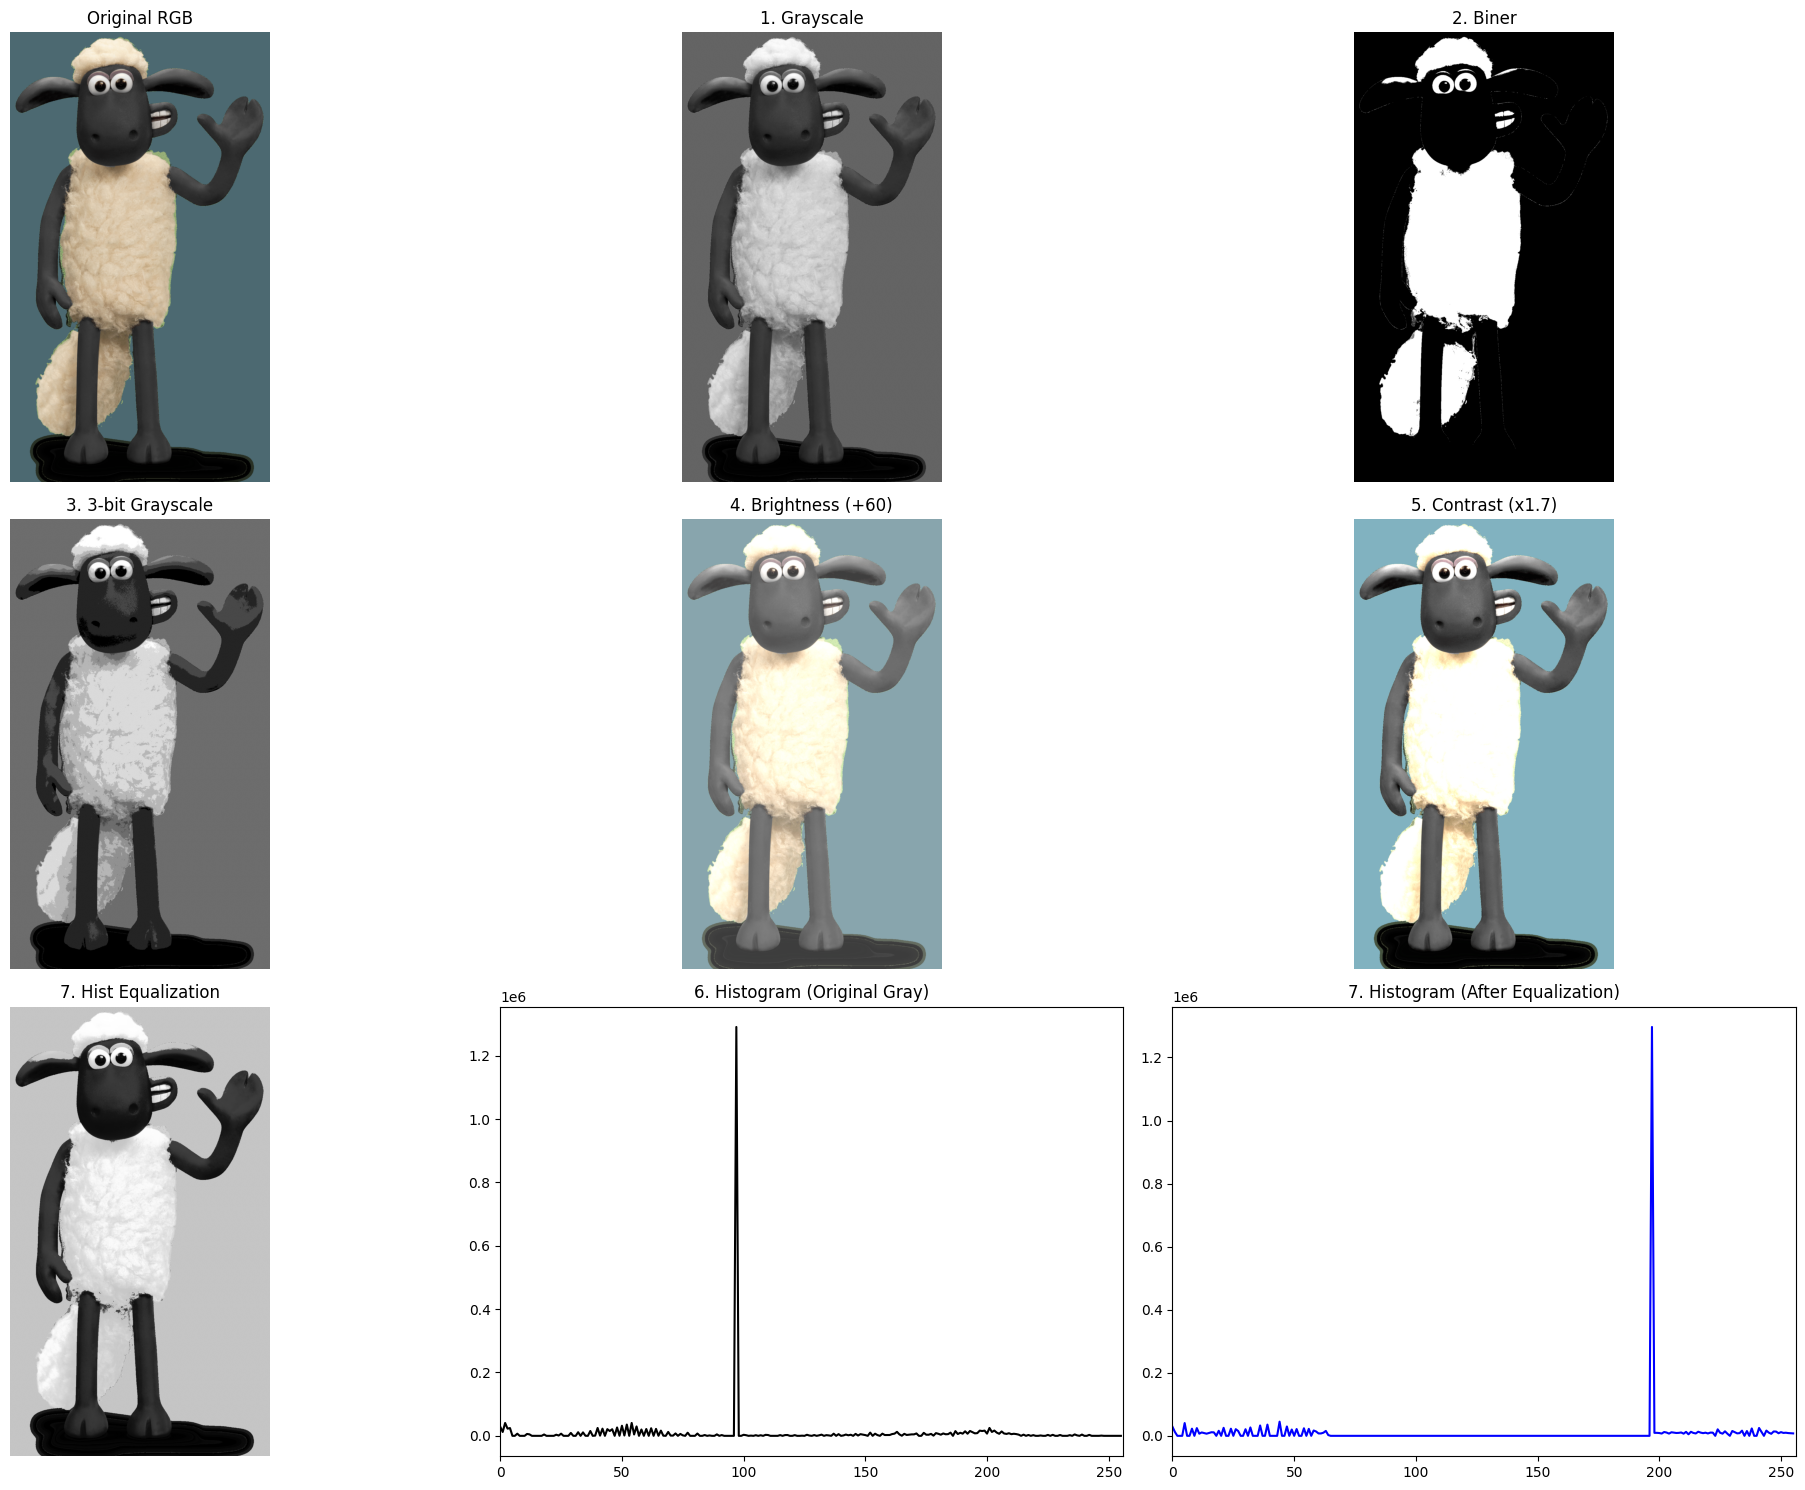

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# 0. Load Gambar
# Pastikan file '531775.png' sudah diupload ke folder 'content' di Colab
img_path = 'stsm2_shaun_004.png'
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 1. Konversi RGB ke Grayscale
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 2. Konversi Grayscale ke Biner (Thresholding)
# Menggunakan threshold 127 sebagai ambang batas tengah
_, biner = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 3. Konversi Grayscale ke m-bit (Contoh: 3-bit / 8 Level)
m = 3
levels = 2**m
mbit = (np.floor(gray / (256 / levels)) * (255 / (levels - 1))).astype(np.uint8)

# 4. Image Brightness (Peningkatan Kecerahan)
bright = cv2.convertScaleAbs(img_rgb, alpha=1, beta=60)

# 5. Image Contrast (Peningkatan Kontras)
contrast = cv2.convertScaleAbs(img_rgb, alpha=1.7, beta=0)

# 6 & 7. Histogram & Histogram Equalization
hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])
equalized = cv2.equalizeHist(gray)
hist_equalized = cv2.calcHist([equalized], [0], None, [256], [0, 256])

# Visualisasi Hasil
titles = ['Original RGB', '1. Grayscale', '2. Biner', f'3. {m}-bit Grayscale',
          '4. Brightness (+60)', '5. Contrast (x1.7)', '7. Hist Equalization']
images = [img_rgb, gray, biner, mbit, bright, contrast, equalized]

plt.figure(figsize=(20, 15))
for i in range(len(images)):
    plt.subplot(3, 3, i+1)
    if len(images[i].shape) == 2: # Citra 2D (Gray/Biner)
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

# Plot Histogram (Poin 6)
plt.subplot(3, 3, 8)
plt.plot(hist_original, color='black')
plt.title('6. Histogram (Original Gray)')
plt.xlim([0, 256])

plt.subplot(3, 3, 9)
plt.plot(hist_equalized, color='blue')
plt.title('7. Histogram (After Equalization)')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

1.RGB ke Grayscale
Menghilangkan informasi warna (kromatisitas) dan menyisakan informasi kecerahan (luminansi). Mengubah citra 3-channel menjadi 1-channel untuk mempercepat proses komputasi.

2.Grayscale ke Biner
Proses pemisahan objek dari latar belakang dengan mengubah piksel hanya menjadi dua nilai: hitam (0) atau putih (255) berdasarkan nilai ambang (threshold).

3.Grayscale ke M-Bit
Teknik kuantisasi untuk mengurangi jumlah level keabuan (misal 8-bit ke 3-bit). Hasilnya menciptakan efek posterize karena gradasi warna yang halus dipaksa menjadi beberapa tingkatan saja.

4.Peningkatan Brightness
Menambahkan nilai konstanta (bias) ke setiap piksel secara merata. Hasilnya, keseluruhan gambar akan tampak lebih terang tanpa mengubah rasio perbedaan antar warna

5.Peningkatan Contrast
Mengalikan nilai piksel dengan faktor skala tertentu. Tujuannya memperlebar rentang intensitas antara area gelap dan terang sehingga detail objek tampak lebih menonjol

6.Grayscale to Histogram
Representasi grafik (diagram batang) yang menunjukkan distribusi frekuensi kemunculan setiap nilai intensitas piksel (0-255) dalam sebuah citra

7.Histogram Equalization
Metode otomatis untuk memperbaiki kontras dengan cara meratakan distribusi intensitas piksel. Sangat berguna untuk citra yang terlalu gelap atau terlalu terang (underexposed/overexposed).

8.Referensi Jurnal
Pemanfaatan teknik ini secara nyata ditemukan pada sistem OCR (pengenalan teks), Face Recognition (pra-pengolahan wajah), dan Citra Medis (memperjelas hasil rontgen/X-ray).